<a href="https://colab.research.google.com/github/SaimNaveed646/ML_Models/blob/main/Pandas/pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to data structures

We’ll start with a quick, non-comprehensive overview of the fundamental data structures in pandas to get you started. The fundamental behavior about data types, indexing, axis labeling, and alignment apply across all of the objects. To get started, import NumPy and load pandas into your namespace:

In [ ]:
import numpy as np
import pandas as pd

Fundamentally, data alignment is intrinsic. The link between labels and data will not be broken unless done so explicitly by you.

We’ll give a brief intro to the data structures, then consider all of the broad categories of functionality and methods in separate sections.

# Series
Series is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index. The basic method to create a Series is to call:

In [ ]:
# s = pd.Series(data, index=index)

Here, data can be many different things:

*   a Python dict
*   an ndarray
*   a scalar value (like 5)

The passed index is a list of axis labels. Thus, this separates into a few cases depending on what data is:


# From ndarray

If data is an ndarray, index must be the same length as data. If no index is passed, one will be created having values [0, ..., len(data) - 1].


In [ ]:
s = pd.Series(np.random.randn(5), index=["a", "b", "c", "d", "e"])
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,-0.370985


In [ ]:
s.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [ ]:
pd.Series(np.random.randn(5))

,0
0,-1.617586
1,0.089840
2,1.011394
3,-0.604434
4,-0.898458


pandas supports non-unique index values. If an operation that does not support duplicate index values is attempted, an exception will be raised at that time.

# From dict


Series can be instantiated from dicts:

In [ ]:
d = {"b": 1, "a": 0, "c": 2}

In [ ]:
pd.Series(d)

,0
b,1
a,0
c,2


If an index is passed, the values in data corresponding to the labels in the index will be pulled out.

In [ ]:
d = {"a": 0.0, "b": 1.0, "c": 2.0}

In [ ]:
pd.Series(d)

,0
a,0.0
b,1.0
c,2.0


In [ ]:
pd.Series(d, index=["b", "c", "d", "a"])

,0
b,1.0
c,2.0
d,NaN
a,0.0


NaN (not a number) is the standard missing data marker used in pandas.

# From scalar value


If data is a scalar value, an index must be provided. The value will be repeated to match the length of index.

In [ ]:
pd.Series(5.0, index=["a", "b", "c", "d", "e"])

,0
a,5.0
b,5.0
c,5.0
d,5.0
e,5.0


# Series is ndarray-like

Series acts very similarly to a ndarray and is a valid argument to most NumPy functions. However, operations such as slicing will also slice the index

In [ ]:
s.iloc[0]

np.float64(-0.7712549932596076)

In [ ]:
s.iloc[:3]

,0
a,-0.771255
b,-1.741709
c,-2.409908


In [ ]:
s[s > s.median()]

,0
d,0.548902
e,-0.370985


In [ ]:
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,-0.370985


In [ ]:
s.iloc[[4, 3, 1]]

,0
e,-0.370985
d,0.548902
b,-1.741709


In [ ]:
np.exp(s)

,0
a,0.462432
b,0.175221
c,0.089824
d,1.731350
e,0.690054


Like a NumPy array, a pandas Series has a single dtype.

In [ ]:
s.dtype

dtype('float64')

This is often a NumPy dtype. However, pandas and 3rd-party libraries extend NumPy’s type system in a few places, in which case the dtype would be an ExtensionDtype. Some examples within pandas are Categorical data and Nullable integer data type.

If you need the actual array backing a Series, use Series.array.

In [ ]:
s.array

<NumpyExtensionArray>
[ np.float64(-0.7712549932596076),  np.float64(-1.7417085407001662),
  np.float64(-2.4099081609521327),   np.float64(0.5489016627681261),
 np.float64(-0.37098470791391097)]
Length: 5, dtype: float64

Accessing the array can be useful when you need to do some operation without the index

Series.array will always be an ExtensionArray. Briefly, an ExtensionArray is a thin wrapper around one or more concrete arrays like a numpy.ndarray. pandas knows how to take an ExtensionArray and store it in a Series or a column of a DataFrame.

While Series is ndarray-like, if you need an actual ndarray, then use Series.to_numpy().

In [ ]:
s.to_numpy()

array([-0.77125499, -1.74170854, -2.40990816,  0.54890166, -0.37098471])

Even if the Series is backed by a ExtensionArray, Series.to_numpy() will return a NumPy ndarray.

# Series is dict-like

A Series is also like a fixed-size dict in that you can get and set values by index label

In [ ]:
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,-0.370985


In [ ]:
s["a"]

np.float64(-0.7712549932596076)

In [ ]:
s["e"] = 12.0

In [ ]:
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,12.000000


In [ ]:
"e" in s

True

In [ ]:
"f" in s

False

If a label is not contained in the index, an exception is raised:

In [ ]:
s["f"]

KeyError: 'f'

Using the Series.get() method, a missing label will return None or specified default:

In [ ]:
s.get("f")

In [ ]:
s.get("f", np.nan)

nan

These labels can also be accessed by attribute.

# Vectorized operations and label alignment with Series

When working with raw NumPy arrays, looping through value-by-value is usually not necessary. The same is true when working with Series in pandas. Series can also be passed into most NumPy methods expecting an ndarray.

In [ ]:
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,12.000000


In [ ]:
s+s

,0
a,-1.542510
b,-3.483417
c,-4.819816
d,1.097803
e,24.000000


In [ ]:
s * 2

,0
a,-1.542510
b,-3.483417
c,-4.819816
d,1.097803
e,24.000000


In [ ]:
np.exp(s)

,0
a,0.462432
b,0.175221
c,0.089824
d,1.731350
e,162754.791419


A key difference between Series and ndarray is that operations between Series automatically align the data based on label. Thus, you can write computations without giving consideration to whether the Series involved have the same labels.

In [ ]:
s

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902
e,12.000000


In [ ]:
s.iloc[1:]

,0
b,-1.741709
c,-2.409908
d,0.548902
e,12.000000


In [ ]:
s.iloc[:-1]

,0
a,-0.771255
b,-1.741709
c,-2.409908
d,0.548902


In [ ]:
s.iloc[1:] + s.iloc[:-1]

,0
a,NaN
b,-3.483417
c,-4.819816
d,1.097803
e,NaN


The result of an operation between unaligned Series will have the union of the indexes involved. If a label is not found in one Series or the other, the result will be marked as missing NaN. Being able to write code without doing any explicit data alignment grants immense freedom and flexibility in interactive data analysis and research. The integrated data alignment features of the pandas data structures set pandas apart from the majority of related tools for working with labeled data.

In general, we chose to make the default result of operations between differently indexed objects yield the union of the indexes in order to avoid loss of information. Having an index label, though the data is missing, is typically important information as part of a computation. You of course have the option of dropping labels with missing data via the dropna function.



# DataFrame

DataFrame is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it like a spreadsheet or SQL table, or a dict of Series objects. It is generally the most commonly used pandas object. Like Series, DataFrame accepts many different kinds of input


*   Dict of 1D ndarrays, lists, dicts, or Series
*   2-D numpy.ndarray
*   Structured or record ndarray
*   A Series
*   Another DataFrame




Along with the data, you can optionally pass index (row labels) and columns (column labels) arguments. If you pass an index and / or columns, you are guaranteeing the index and / or columns of the resulting DataFrame. Thus, a dict of Series plus a specific index will discard all data not matching up to the passed index.

If axis labels are not passed, they will be constructed from the input data based on common sense rules.

# From dict of Series or dicts

The resulting index will be the union of the indexes of the various Series. If there are any nested dicts, these will first be converted to Series. If no columns are passed, the columns will be the ordered list of dict keys.

In [ ]:
d = {
    "one": pd.Series([1.0, 2.0, 3.0], index=["a", "b", "c"]),
    "two": pd.Series([1.0, 2.0, 3.0, 4.0], index=["a", "b", "c", "d"]),
}

In [ ]:
df = pd.DataFrame(d)
df

,one,two
a,1.0,1.0
b,2.0,2.0
c,3.0,3.0
d,NaN,4.0


In [ ]:
pd.DataFrame(d, index=["d", "b", "a"])

,one,two
d,NaN,4.0
b,2.0,2.0
a,1.0,1.0


In [ ]:
pd.DataFrame(d, index=["d", "b", "a"], columns=["two", "three"])

,two,three
d,4.0,NaN
b,2.0,NaN
a,1.0,NaN


The row and column labels can be accessed respectively by accessing the index and columns attributes:

When a particular set of columns is passed along with a dict of data, the passed columns override the keys in the dict.

In [ ]:
df.index

Index(['a', 'b', 'c', 'd'], dtype='object')

In [ ]:
df.columns

Index(['one', 'two'], dtype='object')

# From dict of ndarrays / lists

In [ ]:
d = {"one": [1.0, 2.0, 3.0, 4.0], "two": [4.0, 3.0, 2.0, 1.0]}

In [ ]:
pd.DataFrame(d)

,one,two
0,1.0,4.0
1,2.0,3.0
2,3.0,2.0
3,4.0,1.0


In [ ]:
pd.DataFrame(d, index=["a", "b", "c", "d"])

,one,two
a,1.0,4.0
b,2.0,3.0
c,3.0,2.0
d,4.0,1.0


# From structured or record array
This case is handled identically to a dict of arrays.

In [ ]:
data = np.zeros((2,), dtype=[("A", "i4"), ("B", "f4"), ("C", "a10")])

/tmp/ipython-input-1409807540.py:1: DeprecationWarning: Data type alias 'a' was deprecated in NumPy 2.0. Use the 'S' alias instead.
  data = np.zeros((2,), dtype=[("A", "i4"), ("B", "f4"), ("C", "a10")])


In [ ]:
data[:] = [(1, 2.0, "Hello"), (2, 3.0, "World")]

In [ ]:
pd.DataFrame(data)

,A,B,C
0,1,2.0,b'Hello'
1,2,3.0,b'World'


In [ ]:
pd.DataFrame(data, columns=["C", "A", "B"])

,C,A,B
0,b'Hello',1,2.0
1,b'World',2,3.0


DataFrame is not intended to work exactly like a 2-dimensional NumPy ndarray.

# From a list of dicts

In [ ]:
data2 = [{"a": 1, "b": 2}, {"a": 5, "b": 10, "c": 20}]

In [ ]:
pd.DataFrame(data2)

,a,b,c
0,1,2,NaN
1,5,10,20.0


In [ ]:
pd.DataFrame(data2, index=["first", "second"])

,a,b,c
first,1,2,NaN
second,5,10,20.0


In [ ]:
pd.DataFrame(data2, columns=["a", "b"])

,a,b
0,1,2
1,5,10


# From a dict of tuples
You can automatically create a MultiIndexed frame by passing a tuples dictionary.

In [ ]:
pd.DataFrame(
    {
        ("a", "b"): {("A", "B"): 1, ("A", "C"): 2},
        ("a", "a"): {("A", "C"): 3, ("A", "B"): 4},
        ("a", "c"): {("A", "B"): 5, ("A", "C"): 6},
        ("b", "a"): {("A", "C"): 7, ("A", "B"): 8},
        ("b", "b"): {("A", "D"): 9, ("A", "B"): 10},
    }
)

a              b      
       b    a    c    a     b
A B  1.0  4.0  5.0  8.0  10.0
  C  2.0  3.0  6.0  7.0   NaN
  D  NaN  NaN  NaN  NaN   9.0

# From a Series
The result will be a DataFrame with the same index as the input Series, and with one column whose name is the original name of the Series (only if no other column name provided).

In [ ]:
ser = pd.Series(range(3), index=list("abc"), name="ser")

In [ ]:
pd.DataFrame(ser)

,ser
a,0
b,1
c,2


# From a list of namedtuples
The field names of the first namedtuple in the list determine the columns of the DataFrame. The remaining namedtuples (or tuples) are simply unpacked and their values are fed into the rows of the DataFrame. If any of those tuples is shorter than the first namedtuple then the later columns in the corresponding row are marked as missing values. If any are longer than the first namedtuple, a ValueError is raised.

In [ ]:
from collections import namedtuple
Point = namedtuple("Point", "x y")
pd.DataFrame([Point(0, 0), Point(0, 3), (2, 3)])

,x,y
0,0,0
1,0,3
2,2,3


In [ ]:
Point3D = namedtuple("Point3D", "x y z")

In [ ]:
pd.DataFrame([Point3D(0, 0, 0), Point3D(0, 3, 5), Point(2, 3)])

,x,y,z
0,0,0,0.0
1,0,3,5.0
2,2,3,NaN


# From a list of dataclasses
Data Classes as introduced in PEP557, can be passed into the DataFrame constructor. Passing a list of dataclasses is equivalent to passing a list of dictionaries.

Please be aware, that all values in the list should be dataclasses, mixing types in the list would result in a TypeError.

In [ ]:
from dataclasses import make_dataclass

In [ ]:
Point = make_dataclass("Point", [("x", int), ("y", int)])

In [ ]:
pd.DataFrame([Point(0, 0), Point(0, 3), Point(2, 3)])

,x,y
0,0,0
1,0,3
2,2,3


# Missing data

To construct a DataFrame with missing data, we use np.nan to represent missing values. Alternatively, you may pass a numpy.MaskedArray as the data argument to the DataFrame constructor, and its masked entries will be considered missing. See Missing data for more.

# Alternate constructors
# DataFrame.from_dict

DataFrame.from_dict() takes a dict of dicts or a dict of array-like sequences and returns a DataFrame. It operates like the DataFrame constructor except for the orient parameter which is 'columns' by default, but which can be set to 'index' in order to use the dict keys as row labels.

In [ ]:
pd.DataFrame.from_dict(dict([("A", [1, 2, 3]), ("B", [4, 5, 6])]))

,A,B
0,1,4
1,2,5
2,3,6


If you pass orient='index', the keys will be the row labels. In this case, you can also pass the desired column names:

In [ ]:
pd.DataFrame.from_dict(
    dict([("A", [1, 2, 3]), ("B", [4, 5, 6])]),
    orient="index",
    columns=["one", "two", "three"],
)

,one,two,three
A,1,2,3
B,4,5,6


# DataFrame.from_records

DataFrame.from_records() takes a list of tuples or an ndarray with structured dtype. It works analogously to the normal DataFrame constructor, except that the resulting DataFrame index may be a specific field of the structured dtype.

In [ ]:
data

array([(1, 2., b'Hello'), (2, 3., b'World')],
      dtype=[('A', '<i4'), ('B', '<f4'), ('C', 'S10')])

In [ ]:
pd.DataFrame.from_records(data, index="C")

,A,B
C,,
b'Hello',1,2.0
b'World',2,3.0


# Column selection, addition, deletion

You can treat a DataFrame semantically like a dict of like-indexed Series objects. Getting, setting, and deleting columns works with the same syntax as the analogous dict operations:

In [ ]:
df["one"]

,one
a,1.0
b,2.0
c,3.0
d,NaN


In [ ]:
df["three"] = df["one"] * df["two"]

In [ ]:
df["flag"] = df["one"] > 2

In [ ]:
df

,one,two,three,flag
a,1.0,1.0,1.0,False
b,2.0,2.0,4.0,False
c,3.0,3.0,9.0,True
d,NaN,4.0,NaN,False


Columns can be deleted or popped like with a dict:

In [ ]:
del df["two"]

In [ ]:
three = df.pop("three")

In [ ]:
df

,one,flag
a,1.0,False
b,2.0,False
c,3.0,True
d,NaN,False


When inserting a scalar value, it will naturally be propagated to fill the column:

In [ ]:
df["foo"] = "bar"
df

,one,flag,foo
a,1.0,False,bar
b,2.0,False,bar
c,3.0,True,bar
d,NaN,False,bar


When inserting a Series that does not have the same index as the DataFrame, it will be conformed to the DataFrame’s index:

In [ ]:
df["one_trunc"] = df["one"][:2]
df

,one,flag,foo,one_trunc
a,1.0,False,bar,1.0
b,2.0,False,bar,2.0
c,3.0,True,bar,NaN
d,NaN,False,bar,NaN


You can insert raw ndarrays but their length must match the length of the DataFrame’s index.

By default, columns get inserted at the end. DataFrame.insert() inserts at a particular location in the columns:

In [ ]:
df.insert(1, "bar", df["one"])
df

,one,bar,flag,foo,one_trunc
a,1.0,1.0,False,bar,1.0
b,2.0,2.0,False,bar,2.0
c,3.0,3.0,True,bar,NaN
d,NaN,NaN,False,bar,NaN


# Assigning new columns in method chains

Inspired by dplyr’s mutate verb, DataFrame has an assign() method that allows you to easily create new columns that are potentially derived from existing columns.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)
df.sepal

In [ ]:
df = df.rename(columns={"sepal length (cm)": "SepalLength","sepal width (cm)": "SepalWidth","petal length (cm)": "PetalLength","petal width (cm)": "PetalWidth"})


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [ ]:
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df.assign(sepal_ratio=df["SepalWidth"] / df["SepalLength"]).head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,sepal_ratio
0,5.1,3.5,1.4,0.2,0.686275
1,4.9,3.0,1.4,0.2,0.612245
2,4.7,3.2,1.3,0.2,0.680851
3,4.6,3.1,1.5,0.2,0.673913
4,5.0,3.6,1.4,0.2,0.720000


In the example above, we inserted a precomputed value. We can also pass in a function of one argument to be evaluated on the DataFrame being assigned to.

In [ ]:
df.assign(sepal_ratio=lambda x: (x["SepalWidth"] / x["SepalLength"])).head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,sepal_ratio
0,5.1,3.5,1.4,0.2,0.686275
1,4.9,3.0,1.4,0.2,0.612245
2,4.7,3.2,1.3,0.2,0.680851
3,4.6,3.1,1.5,0.2,0.673913
4,5.0,3.6,1.4,0.2,0.720000


assign() always returns a copy of the data, leaving the original DataFrame untouched.

Passing a callable, as opposed to an actual value to be inserted, is useful when you don’t have a reference to the DataFrame at hand. This is common when using assign() in a chain of operations. For example, we can limit the DataFrame to just those observations with a Sepal Length greater than 5, calculate the ratio, and plot:

<Axes: xlabel='SepalRatio', ylabel='PetalRatio'>

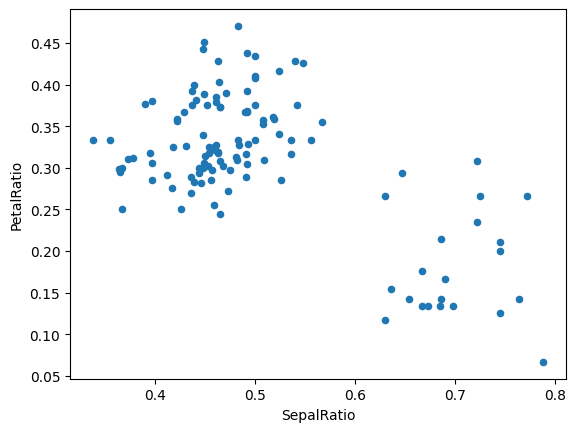

In [ ]:
(
    df.query("SepalLength > 5")
    .assign(
        SepalRatio=lambda x: x.SepalWidth / x.SepalLength,
        PetalRatio=lambda x: x.PetalWidth / x.PetalLength,
    )
    .plot(kind="scatter", x="SepalRatio", y="PetalRatio")
)

Since a function is passed in, the function is computed on the DataFrame being assigned to. Importantly, this is the DataFrame that’s been filtered to those rows with sepal length greater than 5. The filtering happens first, and then the ratio calculations. This is an example where we didn’t have a reference to the filtered DataFrame available.

The function signature for assign() is simply **kwargs. The keys are the column names for the new fields, and the values are either a value to be inserted (for example, a Series or NumPy array), or a function of one argument to be called on the DataFrame. A copy of the original DataFrame is returned, with the new values inserted.

The order of **kwargs is preserved. This allows for dependent assignment, where an expression later in **kwargs can refer to a column created earlier in the same assign().

In [ ]:
dfa = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})

In [ ]:
dfa.assign(C=lambda x: x["A"] + x["B"], D=lambda x: x["A"] + x["C"])

,A,B,C,D
0,1,4,5,6
1,2,5,7,9
2,3,6,9,12


In the second expression, x['C'] will refer to the newly created column, that’s equal to dfa['A'] + dfa['B'].

# Indexing / selection

The basics of indexing are as follows:

| Operation  | Syntax | Result
|------------|--------|--------
| Select column  | df[col]    | Series
| Select row by label | df.loc[label]    | Series
| Select row by integer location| df.iloc[loc]    | Series
| Slice rows| df[5:10]   | DataFrame
| Select rows by boolean vector| df[bool_vec]   | DataFrame


Row selection, for example, returns a Series whose index is the columns of the DataFrame:

In [ ]:
d = {
    "one": pd.Series([1.0, 2.0, 3.0], index=["a", "b", "c"]),
    "two": pd.Series([1.0, 2.0, 3.0, 4.0], index=["a", "b", "c", "d"]),
}
df=pd.DataFrame(d)

In [ ]:
df.loc["b"]

,b
one,2.0
two,2.0


In [ ]:
df.iloc[2]

,c
one,3.0
two,3.0


# Data alignment and arithmetic
Data alignment between DataFrame objects automatically align on both the columns and the index (row labels). Again, the resulting object will have the union of the column and row labels.

In [ ]:
df = pd.DataFrame(np.random.randn(10, 4), columns=["A", "B", "C", "D"])
df

,A,B,C,D
0,0.444567,0.203367,-1.264429,0.754304
1,0.951304,0.033034,-0.071834,0.729254
2,-0.324991,-0.334246,2.428141,1.003488
3,-1.407112,-0.167512,0.425750,-1.433364
4,-1.233388,0.192066,1.836510,-0.008080
5,-2.110141,-0.011585,0.088234,-1.752799
6,-0.048853,0.302300,-0.939464,-0.476534
7,-0.837718,-0.302654,-0.438328,-0.494298
8,-0.223122,-1.108047,1.108102,0.487411
9,0.338581,-1.288198,-1.188508,0.949226


In [ ]:
df2 = pd.DataFrame(np.random.randn(7, 3), columns=["A", "B", "C"])
df2

,A,B,C
0,0.508683,-1.695663,0.229892
1,-0.824850,1.575600,0.528305
2,0.671321,0.999583,0.165974
3,0.554147,1.585558,-1.208317
4,-1.636403,-1.955750,1.535475
5,-1.553742,0.015885,1.029139
6,-0.799050,0.727562,1.007124


In [ ]:
df + df2

,A,B,C,D
0,0.953250,-1.492296,-1.034537,NaN
1,0.126454,1.608634,0.456471,NaN
2,0.346330,0.665337,2.594115,NaN
3,-0.852965,1.418045,-0.782566,NaN
4,-2.869791,-1.763684,3.371985,NaN
5,-3.663883,0.004299,1.117373,NaN
6,-0.847904,1.029862,0.067660,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


When doing an operation between DataFrame and Series, the default behavior is to align the Series index on the DataFrame columns, thus broadcasting row-wise. For example:

In [ ]:
df - df.iloc[0]

,A,B,C,D
0,0.000000,0.000000,0.000000,0.000000
1,0.506737,-0.170333,1.192595,-0.025049
2,-0.769558,-0.537613,3.692570,0.249184
3,-1.851679,-0.370879,1.690179,-2.187668
4,-1.677956,-0.011301,3.100939,-0.762384
5,-2.554708,-0.214952,1.352662,-2.507103
6,-0.493420,0.098933,0.324964,-1.230838
7,-1.282286,-0.506021,0.826100,-1.248602
8,-0.667689,-1.311414,2.372531,-0.266893
9,-0.105986,-1.491565,0.075921,0.194922


Arithmetic operations with scalars operate element-wise:

In [ ]:
df * 5 + 2

,A,B,C,D
0,4.222836,3.016835,-4.322143,5.771520
1,6.756520,2.165169,1.640829,5.646272
2,0.375044,0.328771,14.140706,7.017441
3,-5.035558,1.162438,4.128752,-5.166818
4,-4.166941,2.960331,11.182550,1.959601
5,-8.550703,1.942073,2.441168,-6.763994
6,1.755734,3.511499,-2.697322,-0.382671
7,-2.188592,0.486728,-0.191641,-0.471491
8,0.884390,-3.540234,7.540510,4.437053
9,3.692905,-4.440990,-3.942539,6.746131


In [ ]:
1 / df

,A,B,C,D
0,2.249378,4.917217,-0.790871,1.325725
1,1.051189,30.271946,-13.920961,1.371263
2,-3.077007,-2.991810,0.411838,0.996524
3,-0.710676,-5.969707,2.348794,-0.697660
4,-0.810775,5.206540,0.544511,-123.763946
5,-0.473902,-86.315826,11.333547,-0.570516
6,-20.469479,3.307974,-1.064436,-2.098485
7,-1.193719,-3.304099,-2.281395,-2.023070
8,-4.481854,-0.902489,0.902444,2.051659
9,2.953503,-0.776278,-0.841391,1.053490


In [ ]:
df ** 4

,A,B,C,D
0,0.039062,1.710498e-03,2.556097,3.237320e-01
1,0.818987,1.190800e-06,0.000027,2.828241e-01
2,0.011155,1.248142e-02,34.761275,1.014026e+00
3,3.920254,7.873865e-04,0.032856,4.221098e+00
4,2.314191,1.360828e-03,11.375570,4.262098e-09
5,19.826478,1.801517e-08,0.000061,9.439048e+00
6,0.000006,8.351252e-03,0.778971,5.156752e-02
7,0.492484,8.390500e-03,0.036915,5.969749e-02
8,0.002478,1.507414e+00,1.507714,5.643904e-02
9,0.013142,2.753787e+00,1.995300,8.118558e-01


Boolean operators operate element-wise as well:

In [ ]:
df1 = pd.DataFrame({"a": [1, 0, 1], "b": [0, 1, 1]}, dtype=bool)

In [ ]:
df2 = pd.DataFrame({"a": [0, 1, 1], "b": [1, 1, 0]}, dtype=bool)

In [ ]:
df1 & df2

,a,b
0,False,False
1,False,True
2,True,False


In [ ]:
df1 | df2

,a,b
0,True,True
1,True,True
2,True,True


In [ ]:
df1 ^ df2

,a,b
0,True,True
1,True,False
2,False,True


In [ ]:
-df1

,a,b
0,False,True
1,True,False
2,False,False


# Transposing
To transpose, access the T attribute or DataFrame.transpose(), similar to an ndarray:

In [ ]:
df[:5].T

,0,1,2,3,4
A,0.444567,0.951304,-0.324991,-1.407112,-1.233388
B,0.203367,0.033034,-0.334246,-0.167512,0.192066
C,-1.264429,-0.071834,2.428141,0.425750,1.836510
D,0.754304,0.729254,1.003488,-1.433364,-0.008080


# DataFrame interoperability with NumPy functions

Most NumPy functions can be called directly on Series and DataFrame

In [ ]:
np.exp(df)

,A,B,C,D
0,1.559815,1.225522,0.282401,2.126131
1,2.589083,1.033586,0.930685,2.073534
2,0.722534,0.715878,11.337787,2.727781
3,0.244849,0.845766,1.530739,0.238505
4,0.291304,1.211751,6.274601,0.991953
5,0.121221,0.988481,1.092243,0.173288
6,0.952321,1.352967,0.390837,0.620932
7,0.432697,0.738854,0.645114,0.609999
8,0.800017,0.330203,3.028605,1.628095
9,1.402955,0.275767,0.304676,2.583710


In [ ]:
np.asarray(df)

array([[ 0.44456727,  0.20336706, -1.26442868,  0.75430397],
       [ 0.95130393,  0.03303389, -0.07183412,  0.72925447],
       [-0.32499111, -0.3342458 ,  2.42814113,  1.00348828],
       [-1.40711162, -0.16751241,  0.42575043, -1.4333636 ],
       [-1.23338823,  0.19206615,  1.83650997, -0.0080799 ],
       [-2.11014061, -0.01158536,  0.08823363, -1.75279871],
       [-0.04885322,  0.30229982, -0.93946447, -0.47653419],
       [-0.83771837, -0.30265438, -0.43832827, -0.4942982 ],
       [-0.22312193, -1.10804685,  1.10810198,  0.48741052],
       [ 0.33858102, -1.28819796, -1.18850786,  0.94922622]])

DataFrame is not intended to be a drop-in replacement for ndarray as its indexing semantics and data model are quite different in places from an n-dimensional array.

Series implements __array_ufunc__, which allows it to work with NumPy’s universal functions.

The ufunc is applied to the underlying array in a Series.

In [ ]:
ser = pd.Series([1, 2, 3, 4])

In [ ]:
np.exp(ser)

,0
0,2.718282
1,7.389056
2,20.085537
3,54.598150


When multiple Series are passed to a ufunc, they are aligned before performing the operation.

Like other parts of the library, pandas will automatically align labeled inputs as part of a ufunc with multiple inputs. For example, using numpy.remainder() on two Series with differently ordered labels will align before the operation.

In [ ]:
ser1 = pd.Series([1, 2, 3], index=["a", "b", "c"])
ser1

,0
a,1
b,2
c,3


In [ ]:
ser2 = pd.Series([1, 3, 5], index=["b", "a", "c"])
ser2

,0
b,1
a,3
c,5


In [ ]:
np.remainder(ser1, ser2)

,0
a,1
b,0
c,3


As usual, the union of the two indices is taken, and non-overlapping values are filled with missing values.

In [ ]:
ser3 = pd.Series([2, 4, 6], index=["b", "c", "d"])
ser3

,0
b,2
c,4
d,6


In [ ]:
np.remainder(ser1, ser3)

,0
a,NaN
b,0.0
c,3.0
d,NaN


When a binary ufunc is applied to a Series and Index, the Series implementation takes precedence and a Series is returned.

In [ ]:
ser = pd.Series([1, 2, 3])

In [ ]:
idx = pd.Index([4, 5, 6])

In [ ]:
np.maximum(ser, idx)

,0
0,4
1,5
2,6


NumPy ufuncs are safe to apply to Series backed by non-ndarray arrays, for example arrays.SparseArray (see Sparse calculation). If possible, the ufunc is applied without converting the underlying data to an ndarray.

# DataFrame column attribute access

If a DataFrame column label is a valid Python variable name, the column can be accessed like an attribute:

In [ ]:
df = pd.DataFrame({"foo1": np.random.randn(5), "foo2": np.random.randn(5)})

In [ ]:
df

,foo1,foo2
0,-0.496659,-0.138546
1,0.445625,1.132774
2,1.431499,1.203952
3,-0.615513,-0.602644
4,-1.234857,-0.720526


In [ ]:
df.foo1

,foo1
0,-0.496659
1,0.445625
2,1.431499
3,-0.615513
4,-1.234857


# Chart Visualization

This section demonstrates visualization through charting. We use the standard convention for referencing the matplotlib API:

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.close("all")

# Basic plotting: plot

The plot method on Series and DataFrame is just a simple wrapper around plt.plot():

In [ ]:
np.random.seed(123456)

In [ ]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

In [ ]:
ts = ts.cumsum()

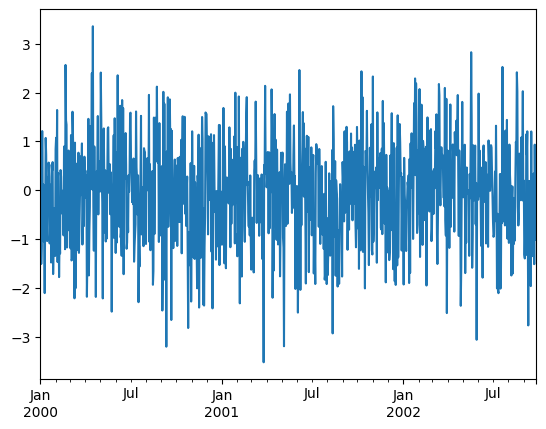

In [ ]:
ts.plot();

If the index consists of dates, it calls gcf().autofmt_xdate() to try to format the x-axis nicely as per above.

On DataFrame, plot() is a convenience to plot all of the columns with labels:

In [ ]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index, columns=list("ABCD"))

In [ ]:
df = df.cumsum()

In [ ]:
plt.figure();

<Figure size 640x480 with 0 Axes>

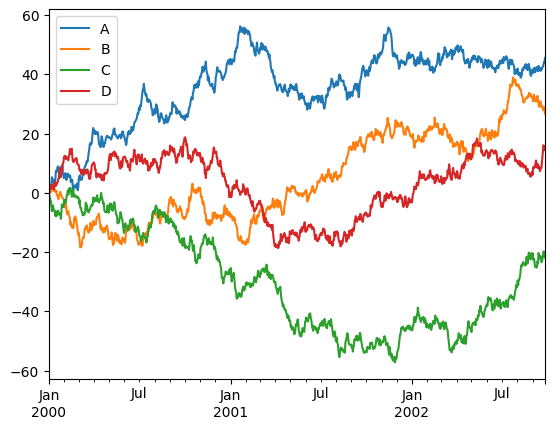

In [ ]:
df.plot();

You can plot one column versus another using the x and y keywords in plot():

In [ ]:
df3 = pd.DataFrame(np.random.randn(1000, 2), columns=["B", "C"]).cumsum()

In [ ]:
df3["A"] = pd.Series(list(range(len(df))))

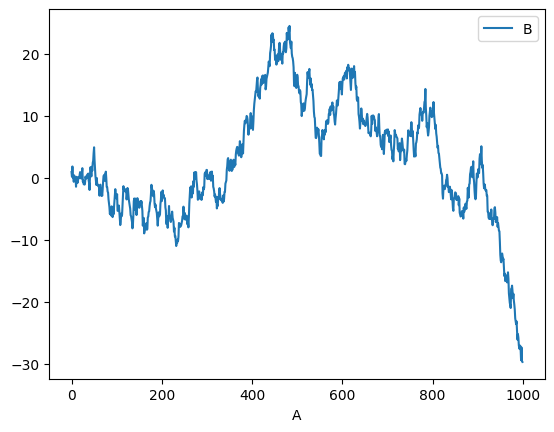

In [ ]:
df3.plot(x="A", y="B");

# Other plots
Plotting methods allow for a handful of plot styles other than the default line plot. These methods can be provided as the kind keyword argument to plot(), and include:

‘bar’ or ‘barh’ for bar plots

‘hist’ for histogram

‘box’ for boxplot

‘kde’ or ‘density’ for density plots

‘area’ for area plots

‘scatter’ for scatter plots

‘hexbin’ for hexagonal bin plots

‘pie’ for pie plots

For example, a bar plot can be created the following way:

In [ ]:
plt.figure();

<Figure size 640x480 with 0 Axes>

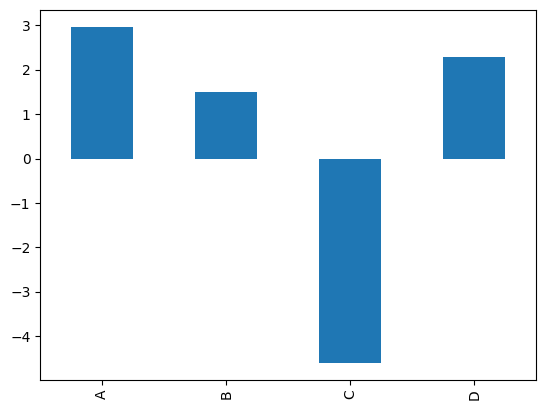

In [ ]:
df.iloc[5].plot(kind="bar");

Finally, there are several plotting functions in pandas.plotting that take a Series or DataFrame as an argument. These include:

Scatter Matrix

Andrews Curves

Parallel Coordinates

Lag Plot

Autocorrelation Plot

Bootstrap Plot

RadViz

Plots may also be adorned with errorbars or tables.

# Bar plots
For labeled, non-time series data, you may wish to produce a bar plot:

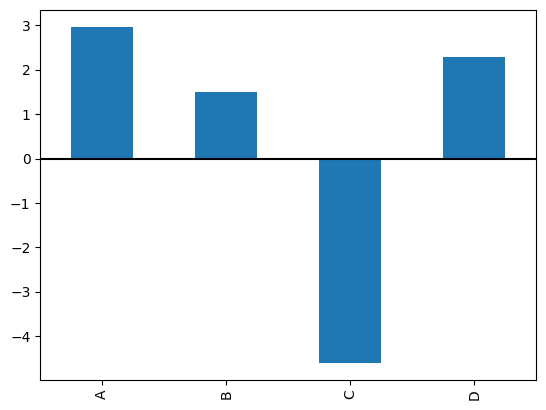

In [ ]:
plt.figure();
df.iloc[5].plot.bar();
plt.axhline(0, color="k");

Calling a DataFrame’s plot.bar() method produces a multiple bar plot:

In [ ]:
df2 = pd.DataFrame(np.random.rand(10, 4), columns=["a", "b", "c", "d"])

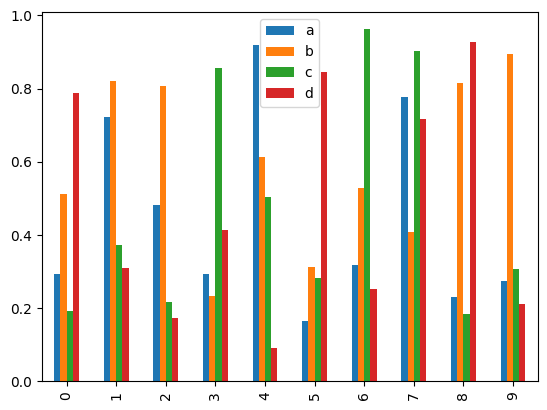

In [ ]:
df2.plot.bar();

To produce a stacked bar plot, pass stacked=True:

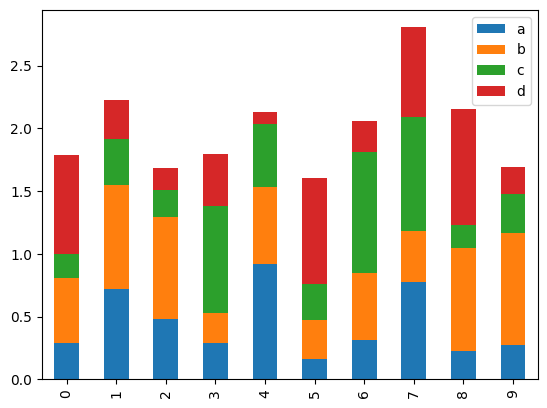

In [ ]:
df2.plot.bar(stacked=True);

To get horizontal bar plots, use the barh method:

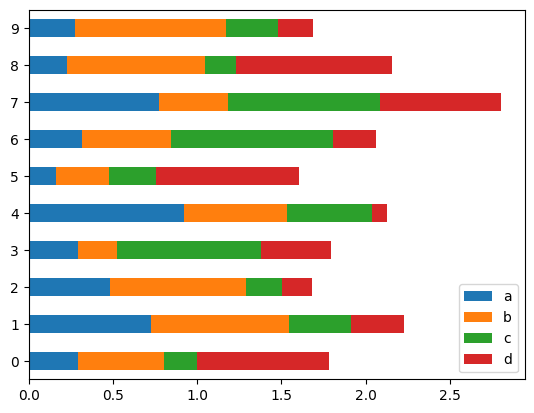

In [ ]:
df2.plot.barh(stacked=True);

# Histograms
Histograms can be drawn by using the DataFrame.plot.hist() and Series.plot.hist() methods.

In [ ]:
df4 = pd.DataFrame(
    {
        "a": np.random.randn(1000) + 1,
        "b": np.random.randn(1000),
        "c": np.random.randn(1000) - 1,
    },
    columns=["a", "b", "c"],
)

In [ ]:
plt.figure();

<Figure size 640x480 with 0 Axes>

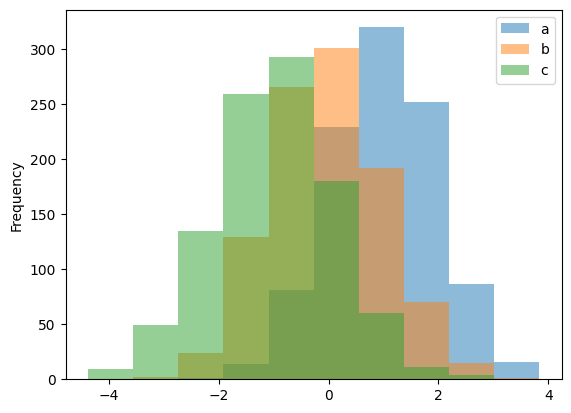

In [ ]:
df4.plot.hist(alpha=0.5);

A histogram can be stacked using stacked=True. Bin size can be changed using the bins keyword.

In [ ]:
plt.figure();

<Figure size 640x480 with 0 Axes>

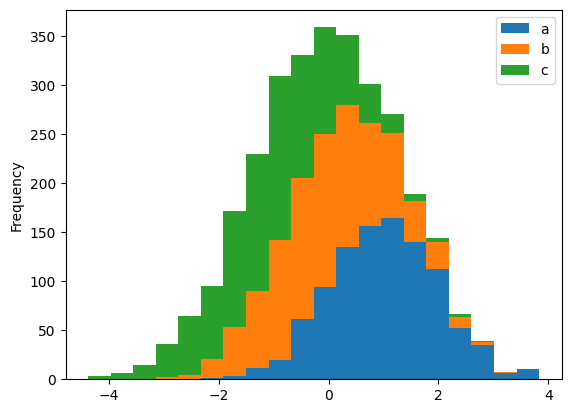

In [ ]:
df4.plot.hist(stacked=True, bins=20);

You can pass other keywords supported by matplotlib hist. For example, horizontal and cumulative histograms can be drawn by orientation='horizontal' and cumulative=True

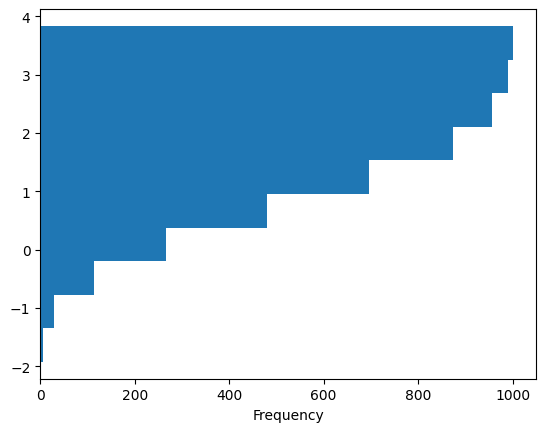

In [ ]:
plt.figure();
df4["a"].plot.hist(orientation="horizontal", cumulative=True);

# Box plots
Boxplot can be drawn calling Series.plot.box() and DataFrame.plot.box(), or DataFrame.boxplot() to visualize the distribution of values within each column.

For instance, here is a boxplot representing five trials of 10 observations of a uniform random variable on [0,1).

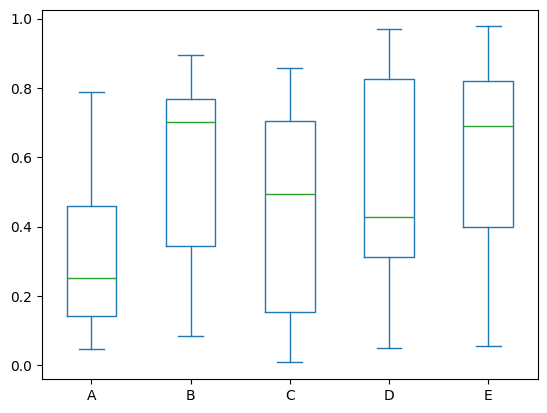

In [ ]:
df = pd.DataFrame(np.random.rand(10, 5), columns=["A", "B", "C", "D", "E"])
df.plot.box();

Boxplot can be colorized by passing color keyword. You can pass a dict whose keys are boxes, whiskers, medians and caps. If some keys are missing in the dict, default colors are used for the corresponding artists. Also, boxplot has sym keyword to specify fliers style.

When you pass other type of arguments via color keyword, it will be directly passed to matplotlib for all the boxes, whiskers, medians and caps colorization.

The colors are applied to every boxes to be drawn. If you want more complicated colorization, you can get each drawn artists by passing return_type.

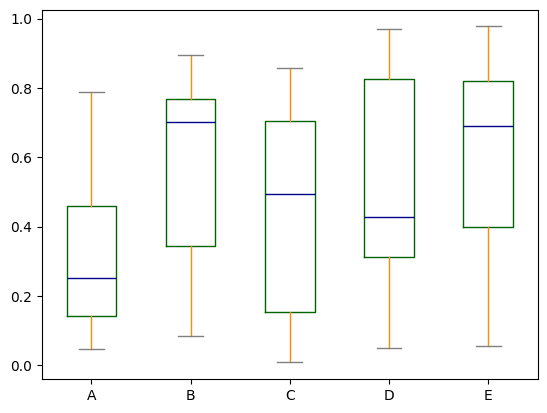

In [ ]:
color = {
    "boxes": "DarkGreen",
    "whiskers": "DarkOrange",
    "medians": "DarkBlue",
    "caps": "Gray",
}
df.plot.box(color=color, sym="r+");

# Area plot
You can create area plots with Series.plot.area() and DataFrame.plot.area(). Area plots are stacked by default. To produce stacked area plot, each column must be either all positive or all negative values.

When input data contains NaN, it will be automatically filled by 0. If you want to drop or fill by different values, use dataframe.dropna() or dataframe.fillna() before calling plot.

In [ ]:
df = pd.DataFrame(np.random.rand(10, 4), columns=["a", "b", "c", "d"])

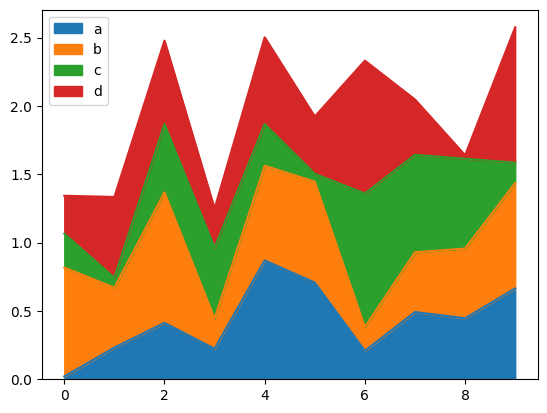

In [ ]:
df.plot.area();

To produce an unstacked plot, pass stacked=False. Alpha value is set to 0.5 unless otherwise specified:

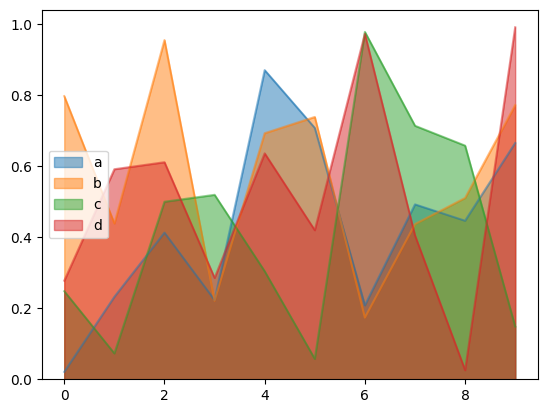

In [ ]:
df.plot.area(stacked=False);

# Scatter plot
Scatter plot can be drawn by using the DataFrame.plot.scatter() method. Scatter plot requires numeric columns for the x and y axes. These can be specified by the x and y keywords.

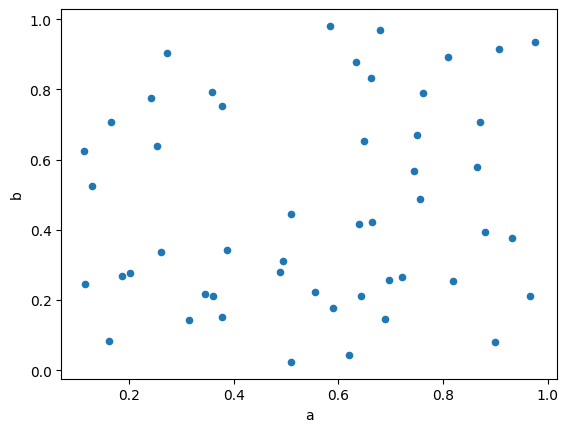

In [ ]:
df = pd.DataFrame(np.random.rand(50, 4), columns=["a", "b", "c", "d"])

df["species"] = pd.Categorical(
    ["setosa"] * 20 + ["versicolor"] * 20 + ["virginica"] * 10
)


df.plot.scatter(x="a", y="b");

To plot multiple column groups in a single axes, repeat plot method specifying target ax. It is recommended to specify color and label keywords to distinguish each groups.

<Axes: xlabel='c', ylabel='d'>

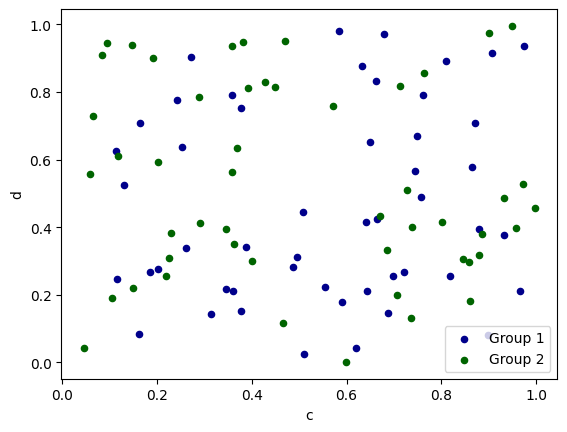

In [ ]:
ax = df.plot.scatter(x="a", y="b", color="DarkBlue", label="Group 1")
df.plot.scatter(x="c", y="d", color="DarkGreen", label="Group 2", ax=ax)

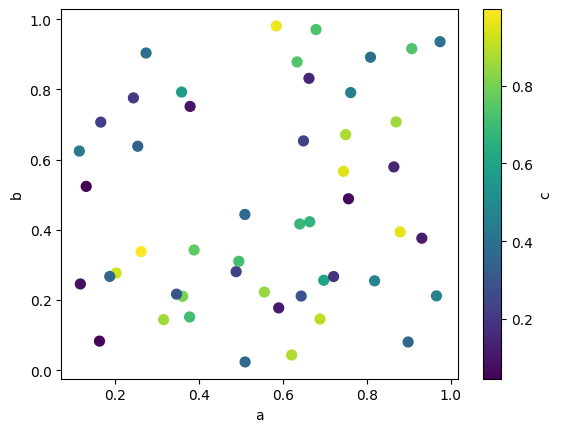

In [ ]:
df.plot.scatter(x="a", y="b", c="c", s=50);

If a categorical column is passed to c, then a discrete colorbar will be produced:

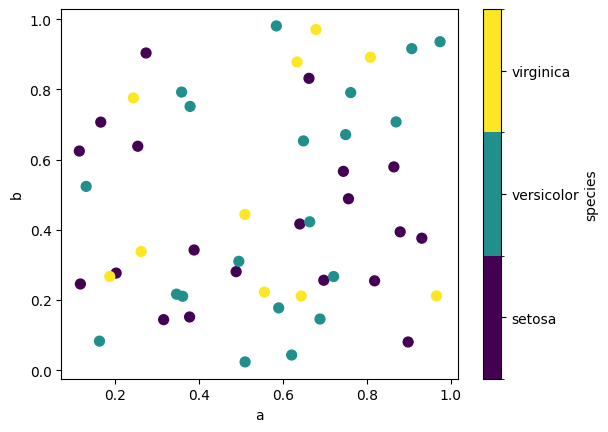

In [ ]:
df.plot.scatter(x="a", y="b", c="species", cmap="viridis", s=50);

# Pie plot
You can create a pie plot with DataFrame.plot.pie() or Series.plot.pie(). If your data includes any NaN, they will be automatically filled with 0. A ValueError will be raised if there are any negative values in your data.

In [ ]:
series = pd.Series(3 * np.random.rand(4), index=["a", "b", "c", "d"], name="series")

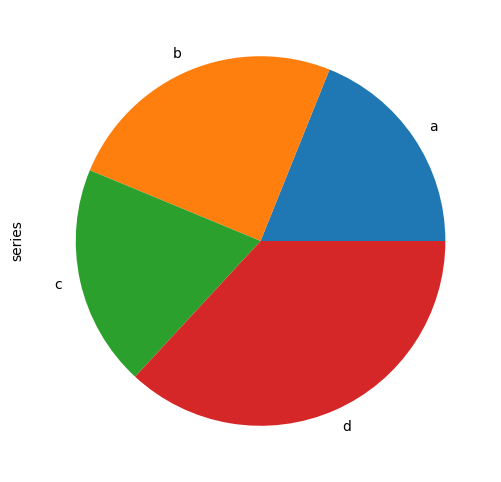

In [ ]:
series.plot.pie(figsize=(6, 6));

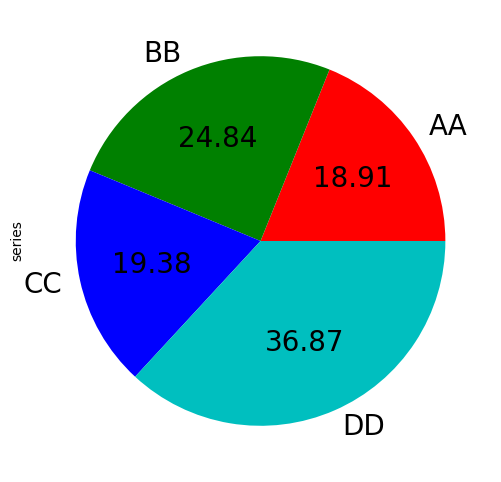

In [ ]:
series.plot.pie(
    labels=["AA", "BB", "CC", "DD"],
    colors=["r", "g", "b", "c"],
    autopct="%.2f",
    fontsize=20,
    figsize=(6, 6),
);


#Plotting with missing data
pandas tries to be pragmatic about plotting DataFrames or Series that contain missing data. Missing values are dropped, left out, or filled depending on the plot type.

| Plot Type  | NaN Handling |
|------|-------|
| Line  | Leave gaps at NaNs    |
| Line (stacked) | Fill 0’s    |
| Bar| Fill 0’s   |
| Scatter| Drop NaNs   |
| Histogram| Drop NaNs (column-wise)   |
| Box| Drop NaNs (column-wise)   |
| Area| Fill 0’s   |
| KDE| Drop NaNs (column-wise)   |
| Hexbin| Drop NaNs   |
| Pie| Fill 0’s   |



If any of these defaults are not what you want, or if you want to be explicit about how missing values are handled, consider using fillna() or dropna() before plotting.

# Reference
https://pandas.pydata.org/